In [1]:
import numpy
from matplotlib import pyplot as plt
import redoxSimulationCopy as redsim
import boxes
import electrode
from sortedcontainers import SortedList
import copy

In [2]:
# here, assume that xy is the total length in the x and y 
# dimensions, rxnZ is the length of the local region, and
# bulkZ is the length of the bulk region
# and teh electrode is at z = 0
# electrode object should already be initialized

class Simulation:
    
    X = 0
    Y = 1
    Z = 2
    ENTER = 0
    COLLIDE = 1
    NOPORE = 2
    NOT_IN_VHT = 3
    
    def __init__(self, xLength, yLength, rxnZ, bulkZ, conc, density, timestep, listOfParticles, startingParticles, electrode, tracker, hasPores = False):
        
        # store in parameters
        self.conc = conc
        self.xLength = xLength
        self.yLength = yLength
        self.localBulkBorder = rxnZ
        self.bottom = rxnZ + bulkZ
        self.timestep = timestep
        self.startingSpecies = startingParticles
        
        # get sigma values
        self.sigma = {}
        for particleType in listOfParticles:
            molDummy = redsim.molecule(0, particleType)
            self.sigma[particleType] = numpy.sqrt(2*molDummy.diffusion*timestep)
        
        # store in electrode parameters
        self.electrode = electrode
        self.hasPores = hasPores
        self.molecules = SortedList()
    
        # initialize a volumeHT for local and bulk regions, and fill 
        # with evenly spaced particles
        # local region
        spaceCoordinatesLocal = [-xLength/2, xLength/2, -yLength/2, yLength/2, 0, rxnZ]
        self.localHT = redsim.volumeHT(spaceCoordinatesLocal, conc, density, boxes.augRadiusBox, listOfParticleTypes = listOfParticles)
        coordinatesToAddLocal = self.initializeCoordinates(spaceCoordinatesLocal)
        for coord in coordinatesToAddLocal:
            newMolecule = redsim.molecule(coord, startingParticles, tracker)
            self.localHT.put(newMolecule)
            self.molecules.add(newMolecule)
            
        # bulk region
        spaceCoordinatesBulk = [-xLength/2, xLength/2, -yLength/2, yLength/2, rxnZ, self.bottom]
        self.bulkHT = redsim.volumeHT(spaceCoordinatesBulk, conc, density, boxes.overlapBox)
        coordinatesToAddBulk = self.initializeCoordinates(spaceCoordinatesBulk)
        for coord in coordinatesToAddBulk:
            newMolecule = redsim.molecule(coord, startingParticles, tracker)
            self.bulkHT.put(newMolecule)
            self.molecules.add(newMolecule)
        
        
    def moveParticle(self, particle, vht, potential):
        moveVector = numpy.random.normal(0, self.sigma[particle.species], 3)
        newPos = self.pbc(moveVector + particle.pos)
        
        # check if enters pore
        if self.hasPores:
            poreEntry = self.electrode.entersPore(particle, newPos)
            if poreEntry == self.ENTER:
                vht.delete(particle)
                self.molecules.remove(particle)
                return
            if poreEntry == self.COLLIDE:
                return
            
        # check if particle close to boundaries
        closeToElectrode = self.closeToElectrode(particle)
        if closeToElectrode:
            newPos = self.electrode.interception(particle, newPos)
        elif self.closeToBorder(particle):
            vht = self.newVHT(vht, newPos)
        else:
            newPos = self.exitSimBox(newPos)
            particle.species = self.startingSpecies
        
        # attempt the move
        vht.attemptMove(particle, newPos)
        if closeToElectrode:
            if self.electrode.hit(particle, potential):
                self.molecules.remove(particle)
                
                
    def moveStuckParticles(self, potential):
        releasedParticles = self.electrode.movingAndShaking(potential)
        for particle in releasedParticles:
            self.molecules.add(particle)
            newPos = self.pbc(self.electrode.rebound(particle))
            attempt = self.localHT.attemptMove(particle, newPos)
            if not attempt:
                self.localHT.put(particle)
        if self.hasPores:
            exiting = self.electrode.movingAndShakingPores(potential)
            for particle in exiting:
                self.molecules.add(particle)
                attempt = self.localHT.put(particle)
                while not attempt:
                    particle.pos = self.pbc(self.electrode.rebound(particle))
                    attempt = self.localHT.put(particle)
    
    def simulate(self, L, potential):
        for i in range(L):
            for mol in copy.copy(self.molecules):
                self.moveParticle(mol, self.getVHT(mol), potential)
            self.moveStuckParticles(potential)
    
                    
    def getVHT(self, particle):
        posZ = particle.pos[self.Z]
        assert posZ >= 0, "pos Z neg"
        if posZ <= self.localBulkBorder:
            return self.localHT
        else:
            return self.bulkHT
    
    def closeToElectrode(self, particle):
        return particle.pos[self.Z] - particle.rad < 3*self.sigma[particle.species]
    
    def closeToBorder(self, particle):
        zPos = particle.pos[self.Z]
        return numpy.abs(zPos - self.localBulkBorder) < 3 * self.sigma[particle.species]
    
    def exitSimBox(self, newPos):
        if newPos[self.Z] <= self.bottom:
            return newPos
        newPosPrime = numpy.array([0, 0, 0])
        for dim in [self.X, self.Y, self.Z]:
            newPosPrime[dim] = numpy.random.uniform(low = self.bulkHT.spaceCoordinates[2*dim], high = self.bulkHT.spaceCoordinates[2*dim+ 1])
        return newPosPrime
            
    def newVHT(self, vht, newPos):
        newZ = newPos[self.Z]
        if (vht == self.localHT) and (newZ > self.localBulkBorder):
            return self.bulkHT
        if (vht == self.bulkHT) and (newZ <= self.localBulkBorder):
            return self.localHT 
        return vht
    
    
    def initializeCoordinates(self, spaceCoordinates):
        simulationBoxLengths = numpy.array([spaceCoordinates[2*i +1] - spaceCoordinates[2*i] for i in range(3)])
        targetN = self.conc * simulationBoxLengths[self.X] * simulationBoxLengths[self.Y] * simulationBoxLengths[self.Z]
        particlesPerDim = int(numpy.ceil(targetN**(1/3)))
        sqSizes = simulationBoxLengths/particlesPerDim
        startCoords = sqSizes/2
        coordinates = []
        coordinates.append([startCoords[self.X] + i*sqSizes[self.X] + spaceCoordinates[2*self.X] for i in range(particlesPerDim)])
        coordinates.append([startCoords[self.Y] + i*sqSizes[self.Y] + spaceCoordinates[2*self.Y] for i in range(particlesPerDim)])
        coordinates.append([startCoords[self.Z] + i*sqSizes[self.Z] + spaceCoordinates[2*self.Z] for i in range(particlesPerDim)])
        
        # product of these arrays
        moleculePositionArray = numpy.zeros((particlesPerDim**3, 3))
        w = 0
        for i in range(particlesPerDim):
            for j in range(particlesPerDim):
                for k in range(particlesPerDim):
                    moleculePositionArray[w, self.X] = coordinates[self.X][i]
                    moleculePositionArray[w, self.Y] = coordinates[self.Y][j]
                    moleculePositionArray[w, self.Z] = coordinates[self.Z][k]
                    w +=1
        return moleculePositionArray
    
    def pbc(self, vector):
        newVector = numpy.zeros(len(vector))
        lengths = [self.xLength, self.yLength]
        for i in [0, 1]:
            coord = vector[i]
            while coord < -lengths[i]/2:
                newVector[i] = coord + lengths[i]
                coord += lengths[i]
            while coord > lengths[i]/2:
                newVector[i] = coord - lengths[i]
                coord -= lengths[i]
            else:
                newVector[i] = coord
        newVector[self.Z] = vector[self.Z]
        return newVector
        
        

In [3]:
ke = 1.44 #in eV * nm/e^2 #electric constant
r4 = 0.351 #nm
r3 = 0.327 #nm
kbt = 2568 #eV at 25C
reducedDensity = 2e-3 * 1e-24 * 6.022e23
d3 = 7.2e-6 *1e14 #nm^2/sec
d4 = 6.7e-6 *1e14
f = 1/kbt
alpha = 0.5
k = 1e-3 #s^-1
k = 1
E0 = 0.2 #eV/e
timestep = 1e-10

In [10]:
el = electrode.electrode2D(0.5, 0, 0.78, timestep)
tracker = redsim.reactorTracker()

simulation = Simulation(45, 45, 160, 40, 9e-5, 0.3, timestep, ['3', '4'], '3', el, tracker, False)

potentials = numpy.concatenate((numpy.linspace(-0.2, 0.6, 30), numpy.linspace(0.6, -0.2, 30)))

def appendZPositions(array, molecules):
    newLine = []
    for molecule in molecules:
        newLine.append(molecule.pos[2])
    array.append(newLine)
    
zArray = []

for potential in potentials:
    simulation.simulate(400, potential)
    tracker.timestep()
    appendZPositions(zArray, simulation.molecules)

    


72


([<matplotlib.axis.XTick at 0x116c0ec10>,
 [Text(0.0, 0, '0.00e+00'),
  Text(5.0, 0, '5.00e-07'),
  Text(10.0, 0, '1.00e-06'),
  Text(15.0, 0, '1.50e-06'),
  Text(20.0, 0, '2.00e-06'),
  Text(25.0, 0, '2.50e-06'),
  Text(30.0, 0, '3.00e-06')])

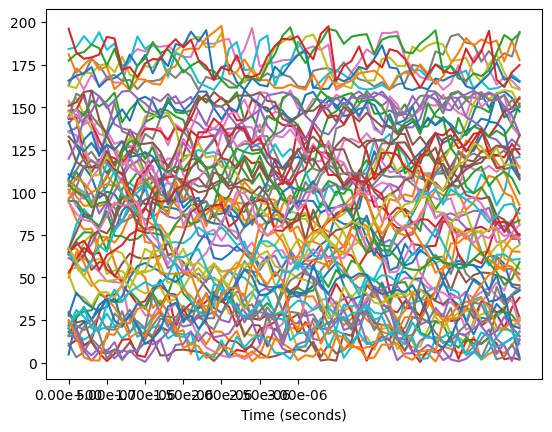

In [11]:
zMatrix = numpy.matrix(zArray)
print(len(zArray[0]))
plt.plot(zArray)
plt.xlabel("Time (seconds)")
ticks = numpy.linspace(0, timestep*30*1000, 7)
ticks = ["{:.2e}".format(number) for number in ticks]
plt.xticks(numpy.linspace(0, 30, 7), ticks)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 14, 5, 2, 6, 7, 5, 7, 4, 5, 3, 4, 4, 2, 3, 6, 10, 2, 1, 2, 2, 4, 0, 1, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


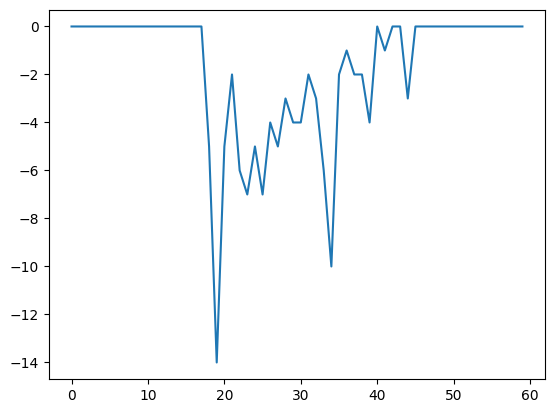

In [14]:
plt.plot(tracker.alphCurrent)
print(tracker.oxidationLog)
print(tracker.reductionLog)

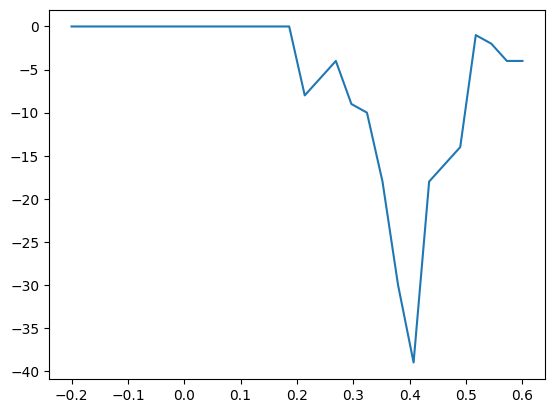

In [8]:
plt.plot(potentials, trackerB.alphCurrent)